# 05 — Is the unexplained image signal technical or biological? And does it add to the transcriptome per animal?

**A. Field vs cell.** Notebook 04 found the transcriptome-unexplained image residual is spatially coherent among
same-type neighbours (r ≈ 0.45 for intensities). Coherence can come from (i) a *technical field* (staining,
focus, illumination), (ii) *tissue state* shared by all cells in a neighbourhood, or (iii) cell-type-specific local
state. Split each residual into
- **field** = mean residual of the 30 nearest cells of *other* cell types (same section) — anything shared across
  types; and
- **cell-specific** = residual − β·field (β fitted per type × feature).

Then ask which part tracks biology (distance to lesion within section; lesion vs physiological niche per animal)
and which tracks technical proxies (local background, edge distance).

**B. Animal level.** An outcome the transcriptome did not define: clinical score at sacrifice. Per animal
(25), lumbar cells only (all animals have lumbar tissue; cervical only in relapse-remitting animals), pseudobulk per
cell type; leave-one-animal-out ridge: transcriptome vs transcriptome + image vs image vs a section-membership
baseline (staining batch).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, wilcoxon
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth

plotting.style()
SRC = "notebooks/05_field_vs_cell_and_animal_level.ipynb"
OUT = ROOT / "results" / "05_field_and_animal"
OUT.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
cfg = data.load_config()

fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa["lesion"] = fa.Curated_niche_state.astype(str).str.startswith("Lesion")
fa["phys"] = fa.Curated_niche_state.astype(str) == "Physiological"
fa["lesion_dist_um"] = orth.lesion_distance(fa, fa.lesion.values)

results = {p.stem.replace("_", " ").replace("NK DC", "NK/DC"): pd.read_pickle(p)
           for p in sorted((ROOT / "data" / "residuals").glob("*.pkl"))}
TYPES = list(results)
common = sorted(set.intersection(*[set(r["residuals"].columns) for r in results.values()]))
FAM = data.feature_families(common)
FAM[[c for c in common if c.endswith("_rim_over_ring")]] = "membrane ratio"
CHAN = pd.Series({c: (c.split("_")[0] if c.split("_")[0] in CH else "morph") for c in common})
print(len(TYPES), "types,", len(common), "common features")


def bh(p):
    p = np.asarray(p, float)
    o = np.argsort(p)
    q = p[o] * len(p) / np.arange(1, len(p) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[o] = np.minimum(q, 1)
    return out

14 types, 84 common features


## A. Split residuals into a cross-type field and a cell-specific part

In [2]:
R = pd.concat([r["residuals"][common].assign(cell_type=t) for t, r in results.items()])
meta = fa.loc[R.index, ["section_id", "x_centroid", "y_centroid", "sample_name", "lesion", "phys", "lesion_dist_um",
                        "edge_um", "bnd_bg_local", "dapi_bg_local", "r18s_bg_local", "smavim_bg_local"]]
K = 30
field = np.full((len(R), len(common)), np.nan, np.float32)
vals = R[common].values.astype(np.float32)
types = R.cell_type.values
for _, idx in meta.groupby("section_id", observed=True).indices.items():
    xy = meta.iloc[idx][["x_centroid", "y_centroid"]].values
    _, nn = cKDTree(xy).query(xy, k=min(K * 3, len(idx)))
    nb_types = types[idx][nn]
    other = nb_types != types[idx][:, None]
    other[:, 0] = False
    # first K other-type neighbours
    rank = np.cumsum(other, 1)
    use = other & (rank <= K)
    w = use / np.maximum(use.sum(1, keepdims=True), 1)
    field[idx] = np.einsum("ik,ikf->if", w, vals[idx][nn])
F = pd.DataFrame(field, index=R.index, columns=common)

rows, cellspec = [], {}
for t in TYPES:
    m = (R.cell_type == t).values
    cs = pd.DataFrame(index=R.index[m], columns=common, dtype=np.float32)
    for c in common:
        y, x = R.loc[m, c].values, F.loc[m, c].values
        ok = np.isfinite(x)
        beta = np.polyfit(x[ok], y[ok], 1)[0] if ok.sum() > 50 else 0.0
        r = np.corrcoef(x[ok], y[ok])[0, 1]
        cs[c] = y - beta * np.nan_to_num(x)
        rows.append(dict(cell_type=t, feature=c, r_field=r, frac_var_field=r ** 2))
    cellspec[t] = cs
fv = pd.DataFrame(rows)
fv["family"], fv["channel"] = fv.feature.map(FAM), fv.feature.map(CHAN)
fv.to_csv(OUT / "field_share.csv", index=False)
CS = pd.concat(cellspec.values())
print("median correlation of a cell's residual with the other-type field, by family:")
fv.groupby("family").r_field.median().sort_values(ascending=False).round(3)

median correlation of a cell's residual with the other-type field, by family:


family
intensity: rim        0.386
intensity: cyto       0.383
intensity: nuc        0.371
morphology            0.202
texture (Haralick)    0.169
radial profile        0.110
polarity              0.071
Name: r_field, dtype: float64

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/05_field_and_animal/field_share_heatmap.png')

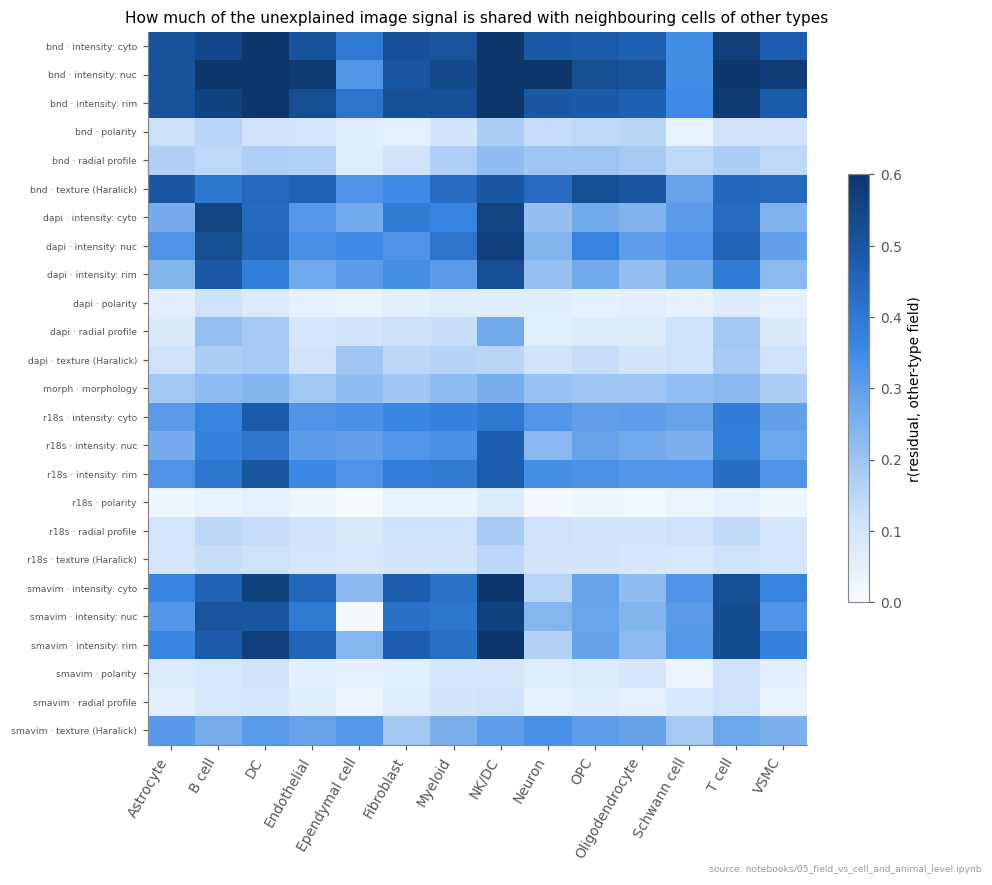

In [3]:
piv = fv.pivot_table(index=["channel", "family"], columns="cell_type", values="r_field").reindex(columns=TYPES)
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(piv.values, cmap=plotting.SEQ, vmin=0, vmax=0.6, aspect="auto")
ax.set_yticks(range(len(piv)), [f"{a} · {b}" for a, b in piv.index], fontsize=6)
ax.set_xticks(range(len(TYPES)), TYPES, rotation=60, ha="right")
fig.colorbar(im, ax=ax, label="r(residual, other-type field)", shrink=0.6)
ax.set_title("How much of the unexplained image signal is shared with neighbouring cells of other types")
fig.tight_layout()
plotting.save_fig(fig, "field_share_heatmap", OUT, SRC)

### What does the field track — technical proxies or lesion biology?
Within each section, Spearman ρ of the field with local background of the same channel, log edge distance, and
log(1 + distance to lesion); median over sections. A field that follows lesion distance but not background is
tissue state; one that follows background/edge is more likely technical.

In [4]:
def within_section_rho(series, other):
    rs = []
    for _, idx in meta.groupby("section_id", observed=True).indices.items():
        a, b = series.values[idx], other.values[idx]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() > 200 and np.std(b[ok]) > 0:
            rs.append(spearmanr(a[ok], b[ok]).statistic)
    return np.median(rs) if rs else np.nan


rows = []
ld = np.log1p(meta.lesion_dist_um)
ed = np.log1p(meta.edge_um.clip(lower=0))
for c in common:
    ch = CHAN[c]
    rows.append(dict(feature=c, family=FAM[c], channel=ch,
                     rho_lesion_dist=within_section_rho(F[c], ld),
                     rho_edge=within_section_rho(F[c], ed),
                     rho_bg=within_section_rho(F[c], meta[f"{ch}_bg_local"]) if ch in CH else np.nan,
                     rho_cellspec_lesion_dist=within_section_rho(CS[c].reindex(R.index), ld)))
ft = pd.DataFrame(rows)
ft.to_csv(OUT / "field_vs_biology_technical.csv", index=False)
ft.groupby(["channel", "family"])[["rho_lesion_dist", "rho_bg", "rho_edge", "rho_cellspec_lesion_dist"]].median().round(3)

rho_lesion_dist  rho_bg  rho_edge  \
channel family                                                  
bnd     intensity: cyto               0.012  -0.125     0.030   
        intensity: nuc               -0.049  -0.552     0.011   
        intensity: rim                0.016  -0.153     0.024   
        polarity                      0.059   0.030    -0.014   
        radial profile               -0.020  -0.080     0.006   
        texture (Haralick)            0.058  -0.045    -0.025   
dapi    intensity: cyto              -0.003   0.170     0.073   
        intensity: nuc               -0.054   0.125    -0.004   
        intensity: rim               -0.033   0.181     0.077   
        polarity                      0.030   0.052     0.020   
        radial profile                0.001  -0.075    -0.035   
        texture (Haralick)            0.025   0.005     0.003   
morph   morphology                    0.030     NaN     0.025   
r18s    intensity: cyto              -0.015  -0.064     0.014   
        intensity: nuc               -0.010  -0.123     0.005   
        intensity: rim               -0.023  -0.076     0.027   
        polarity                      0.015   0.010     0.021   
        radial profile                0.006  -0.068    -0.005   
        texture (Haralick)           -0.006  -0.003    -0.008   
smavim  intensity: cyto               0.009   0.042     0.015   
        intensity: nuc                0.012  -0.275     0.021   
        intensity: rim                0.012   0.027     0.021   
        polarity                     -0.037  -0.160     0.025   
        radial profile                0.014  -0.013    -0.025   
        texture (Haralick)           -0.048  -0.178    -0.011   

                            rho_cellspec_lesion_dist  
channel family                                        
bnd     intensity: cyto                        0.013  
        intensity: nuc                         0.003  
        intensity: rim                         0.015  
        polarity                               0.004  
        radial profile                         0.006  
        texture (Haralick)                     0.001  
dapi    intensity: cyto                       -0.007  
        intensity: nuc                        -0.008  
        intensity: rim                        -0.007  
        polarity                              -0.001  
        radial profile                        -0.003  
        texture (Haralick)                     0.008  
morph   morphology                             0.004  
r18s    intensity: cyto                        0.005  
        intensity: nuc                         0.003  
        intensity: rim                         0.005  
        polarity                               0.003  
        radial profile                         0.000  
        texture (Haralick)                    -0.003  
smavim  intensity: cyto                       -0.020  
        intensity: nuc                         0.005  
        intensity: rim                        -0.018  
        polarity                              -0.000  
        radial profile                        -0.000  
        texture (Haralick)                    -0.003

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/05_field_and_animal/field_lesion_vs_technical.png')

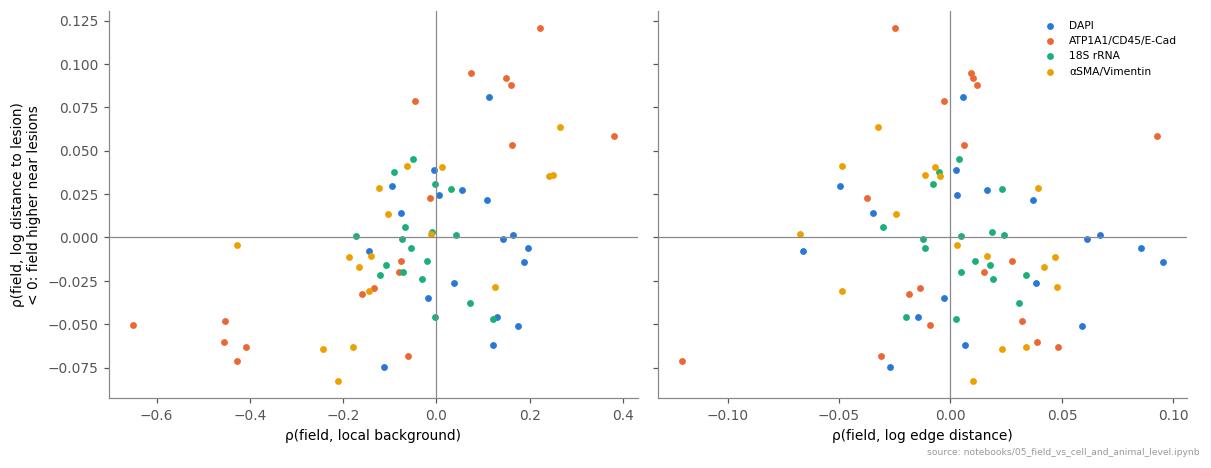

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (x, lab) in zip(axs, (("rho_bg", "ρ(field, local background)"), ("rho_edge", "ρ(field, log edge distance)"))):
    for k, ch in enumerate(CH):
        d = ft[ft.channel == ch]
        ax.scatter(d[x], d.rho_lesion_dist, s=12, color=plotting.CHANNEL_COLORS[ch], label=plotting.CHANNEL_LABELS[ch])
    ax.axhline(0, color="#888888", lw=0.8); ax.axvline(0, color="#888888", lw=0.8)
    ax.set_xlabel(lab)
axs[0].set_ylabel("ρ(field, log distance to lesion)\n< 0: field higher near lesions")
axs[1].legend(fontsize=7)
fig.tight_layout()
plotting.save_fig(fig, "field_lesion_vs_technical", OUT, SRC)

### Does the *cell-specific* part (field removed) still shift with lesion state?
Per animal: mean cell-specific residual in lesion − physiological niche cells (≥ 20 each); Wilcoxon across animals,
BH over type × feature. Compare with the same test on the full residual (notebook 04) and on the field.

In [6]:
def lesion_shift(frame, label):
    rows = []
    for t in TYPES:
        sub = frame.loc[frame.cell_type == t, common]
        m = meta.loc[sub.index]
        diffs = []
        for an, g in m.groupby("sample_name", observed=True):
            L, P = g.index[g.lesion], g.index[g.phys]
            if len(L) >= 20 and len(P) >= 20:
                diffs.append(sub.loc[L].mean() - sub.loc[P].mean())
        if len(diffs) < 5:
            continue
        D = pd.DataFrame(diffs)
        for c in common:
            rows.append(dict(part=label, cell_type=t, feature=c, n_animals=len(D), median_diff=D[c].median(),
                             p=wilcoxon(D[c].dropna()).pvalue if D[c].notna().sum() >= 5 else np.nan))
    out = pd.DataFrame(rows)
    out["q"] = bh(out.p.fillna(1))
    return out


ls = pd.concat([lesion_shift(R, "full residual"), lesion_shift(F.assign(cell_type=R.cell_type), "field"),
                lesion_shift(CS.assign(cell_type=R.loc[CS.index, "cell_type"]), "cell-specific")])
ls["family"] = ls.feature.map(FAM)
ls.to_csv(OUT / "lesion_shift_by_part.csv", index=False)
ls.groupby("part").apply(lambda d: pd.Series({"tests": len(d), "q<0.05": (d.q < 0.05).sum(),
                                              "median |diff| (sig)": d.loc[d.q < 0.05, "median_diff"].abs().median()}),
                         include_groups=False).round(3)

,tests,q<0.05,median |diff| (sig)
part,,,
cell-specific,924.0,19.0,0.095
field,924.0,21.0,0.103
full residual,924.0,19.0,0.117


In [7]:
sig = ls[(ls.part == "cell-specific") & (ls.q < 0.05)].sort_values("median_diff", key=abs, ascending=False)
sig.head(25).round(3)

,part,cell_type,feature,n_animals,median_diff,p,q,family
826,cell-specific,T cell,smavim_glcm_contrast,11,-0.237,0.001,0.047,texture (Haralick)
337,cell-specific,Myeloid,bnd_cyto_p90,19,-0.163,0.000,0.022,intensity: cyto
493,cell-specific,Neuron,smavim_nuc_mean,19,-0.163,0.000,0.022,intensity: nuc
267,cell-specific,Fibroblast,bnd_radial_b4,20,-0.150,0.000,0.030,radial profile
353,cell-specific,Myeloid,bnd_rim_p90,19,-0.150,0.000,0.018,intensity: rim
260,cell-specific,Fibroblast,bnd_nuc_p90,20,0.150,0.001,0.037,intensity: nuc
393,cell-specific,Myeloid,r18s_nuc_p90,19,0.123,0.001,0.037,intensity: nuc
422,cell-specific,Neuron,bnd_glcm_asm,19,0.104,0.001,0.037,texture (Haralick)
874,cell-specific,VSMC,dapi_rim_mean,20,0.098,0.000,0.028,intensity: rim
884,cell-specific,VSMC,morph_nuc_cell_ratio,20,0.095,0.000,0.024,morphology


## B. Animal level: does the image add to the transcriptome for clinical score?
Lumbar cells only. Per animal × cell type (8 most abundant types; ≥ 30 cells per animal, else the type mean is
imputed): transcriptome = mean of 30 within-type PCs of log-normalised counts (PCA fitted on all lumbar cells of the
type; unsupervised); image = mean of rank-INT image features. Leave-one-animal-out ridge (inner GCV for α),
features standardised inside each fold. Baseline: fraction of the animal's cells in each section (staining batch).

In [8]:
adata = ad.read_h5ad(ROOT / cfg["annotation"]["h5ad"])
lum = fa[(fa.region == "L") & (fa.segmentation_method == "Segmented by interior stain (18S)")]
TOP = lum.Anno_L1_curated.value_counts().index[:8].tolist()
animals = sorted(lum.sample_name.unique())
score = lum.groupby("sample_name", observed=True).score_sacrifice.first().reindex(animals)
feat_img = [c for c in common if c in lum.columns]
blocks_tx, blocks_img = [], []
for t in TOP:
    d = lum[lum.Anno_L1_curated == t]
    Xln = orth.lognorm(adata[d.index].X)
    P = PCA(30, svd_solver="covariance_eigh", random_state=0).fit_transform(Xln)
    I = orth.rank_int(d[feat_img]).values
    g = d.sample_name.astype(str).values
    tx = pd.DataFrame(P, index=g).groupby(level=0).mean().reindex(animals)
    im = pd.DataFrame(I, index=g).groupby(level=0).mean().reindex(animals)
    n = pd.Series(g).value_counts().reindex(animals).fillna(0)
    tx[n.values < 30], im[n.values < 30] = np.nan, np.nan
    blocks_tx.append(tx.fillna(tx.mean()).add_prefix(f"{t}|tx"))
    blocks_img.append(im.fillna(im.mean()).add_prefix(f"{t}|img"))
TX, IMG = pd.concat(blocks_tx, axis=1), pd.concat(blocks_img, axis=1)
SECT = pd.crosstab(lum.sample_name, lum.section_id, normalize="index").reindex(animals)
print(TX.shape, IMG.shape, SECT.shape)


def loo(X, y):
    X, y = np.asarray(X, float), np.asarray(y, float)
    pred = np.zeros_like(y)
    for tr, te in LeaveOneOut().split(X):
        mu, sd = X[tr].mean(0), X[tr].std(0) + 1e-9
        m = RidgeCV(alphas=np.logspace(-1, 5, 25)).fit((X[tr] - mu) / sd, y[tr])
        pred[te] = m.predict((X[te] - mu) / sd)
    return pred


preds = {"section membership (batch)": loo(SECT, score), "transcriptome": loo(TX, score),
         "image": loo(IMG, score), "transcriptome + image": loo(pd.concat([TX, IMG], axis=1), score)}
rng = np.random.default_rng(0)
perm = {k: [] for k in preds}
for _ in range(200):
    ys = rng.permutation(score.values)
    for k, X in (("transcriptome", TX), ("image", IMG)):
        perm[k].append(spearmanr(loo(X, ys), ys).statistic)
tab = pd.DataFrame({k: {"R²": 1 - ((score - p) ** 2).sum() / ((score - score.mean()) ** 2).sum(),
                        "Spearman ρ": spearmanr(p, score).statistic} for k, p in preds.items()}).T
for k in ("transcriptome", "image"):
    tab.loc[k, "perm p (ρ)"] = (np.sum(np.array(perm[k]) >= tab.loc[k, "Spearman ρ"]) + 1) / (len(perm[k]) + 1)
tab.to_csv(OUT / "animal_score_prediction.csv")
tab.round(3)

(25, 240) (25, 672) (25, 18)


,R²,Spearman ρ,perm p (ρ)
section membership (batch),-0.152,-0.990,NaN
transcriptome,0.748,0.859,0.005
image,0.284,0.456,0.040
transcriptome + image,0.586,0.735,NaN


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/05_field_and_animal/animal_score_prediction.png')

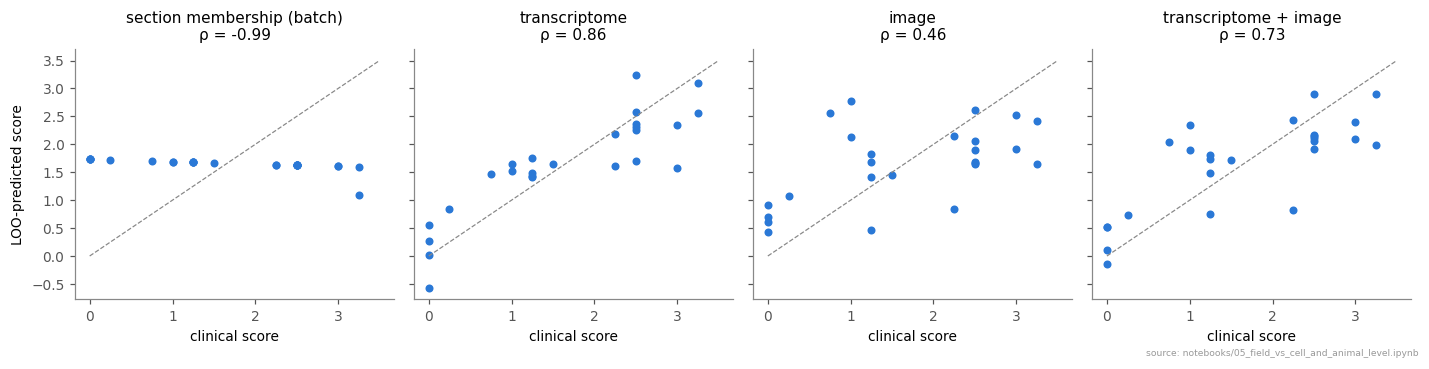

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.3), sharex=True, sharey=True)
for ax, (k, p) in zip(axs, preds.items()):
    ax.scatter(score, p, s=18, color=plotting.CATEGORICAL[0])
    ax.plot([0, 3.5], [0, 3.5], color="#888888", lw=0.8, ls="--")
    ax.set(title=f"{k}\nρ = {tab.loc[k, 'Spearman ρ']:.2f}", xlabel="clinical score")
axs[0].set_ylabel("LOO-predicted score")
fig.tight_layout()
plotting.save_fig(fig, "animal_score_prediction", OUT, SRC)

Which image features carry the animal-level signal? Univariate Spearman ρ of each (type, feature) animal mean with
score, BH-corrected; top hits.

In [10]:
uni = pd.DataFrame([dict(block=c, rho=spearmanr(IMG[c], score).statistic, p=spearmanr(IMG[c], score).pvalue)
                    for c in IMG.columns])
uni["cell_type"] = uni.block.str.split("|").str[0]
uni["feature"] = [feat_img[int(b.split("|img")[1])] for b in uni.block]
uni["q"] = bh(uni.p)
uni.to_csv(OUT / "animal_image_feature_vs_score.csv", index=False)
uni.sort_values("p").head(25)[["cell_type", "feature", "rho", "p", "q"]].round(4)

,cell_type,feature,rho,p,q
297,Fibroblast,morph_nuc_eccentricity,-0.7610,0.0000,0.0067
53,Myeloid,r18s_glcm_correlation,0.7373,0.0000,0.0088
370,Astrocyte,dapi_rim_mean,-0.7213,0.0000,0.0106
389,Astrocyte,r18s_glcm_correlation,0.6917,0.0001,0.0189
473,Endothelial,r18s_glcm_correlation,0.6878,0.0001,0.0189
451,Endothelial,dapi_radial_b2,-0.6808,0.0002,0.0189
371,Astrocyte,dapi_rim_p90,-0.6688,0.0003,0.0189
465,Endothelial,morph_nuc_eccentricity,-0.6688,0.0003,0.0189
390,Astrocyte,r18s_glcm_entropy,0.6684,0.0003,0.0189
406,Astrocyte,smavim_glcm_contrast,-0.6657,0.0003,0.0189


### Is the 18S-texture ↔ score link a section-level (focus/staining) effect?
Per animal × section (lumbar, ≥ 30 cells), median 18S texture correlation; compare animals only with other animals
in the *same section* (both centred on the section mean). DAPI texture is the negative control (same optics).

In [11]:
rows = []
for t in ["Myeloid", "Astrocyte", "Endothelial", "Fibroblast", "Oligodendrocyte", "Neuron"]:
    d = lum[lum.Anno_L1_curated == t]
    a = d.groupby(["section_id", "sample_name"], observed=True).agg(
        v=("r18s_glcm_correlation", "median"), dv=("dapi_glcm_correlation", "median"),
        score=("score_sacrifice", "first"), n=("section_id", "size")).reset_index()
    a = a[a.n >= 30]
    a["v_w"] = a.v - a.groupby("section_id").v.transform("mean")
    a["s_w"] = a.score - a.groupby("section_id").score.transform("mean")
    b = a[(a.groupby("section_id").sample_name.transform("nunique") > 1) & (a.groupby("section_id").score.transform("std") > 0)]
    rows.append(dict(cell_type=t, rho_all=spearmanr(a.v, a.score).statistic,
                     rho_within_section=spearmanr(b.v_w, b.s_w).statistic, n_within=len(b),
                     rho_dapi_texture=spearmanr(a.dv, a.score).statistic))
tex = pd.DataFrame(rows).set_index("cell_type")
tex.to_csv(OUT / "r18s_texture_within_section.csv")
tex.round(2)

,rho_all,rho_within_section,n_within,rho_dapi_texture
cell_type,,,,
Myeloid,0.76,0.84,12,0.13
Astrocyte,0.72,0.84,12,-0.18
Endothelial,0.71,0.86,12,0.39
Fibroblast,0.67,0.67,12,0.18
Oligodendrocyte,0.50,0.53,12,-0.15
Neuron,0.37,0.67,12,-0.13
